<a href="https://colab.research.google.com/github/mostafaelhussien/hands-on-machine-learning/blob/main/Chapter_2_End_to_End_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: End-to-End Machine Learning Project

**California Housing Prices Prediction**

This notebook follows **Chapter 2** from the book *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd Edition) by Aurélien Géron.

### Objectives:
- Understand the full Machine Learning project workflow
- Learn how to prepare real-world data
- Build and evaluate a regression model

**Author:** Mostafa  
**Date:** April 2026

In [ ]:
# =============================================
# Chapter 2 - End-to-End ML Project
# California Housing Prices
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint

# To make plots look better
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# ====================== رفع الملف من الكمبيوتر ======================
from google.colab import files
import io

print("Please upload your housing.csv file...")
uploaded = files.upload()

# بعد ما ترفع الملف، هنقرأه
import pandas as pd

# قراءة الملف من المحتوى المرفوع
# Assuming the uploaded file is 'housing.csv'
file_name = list(uploaded.keys())[0]
housing = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("✅ تم تحميل الملف بنجاح!")
print(f"شكل الداتا: {housing.shape} (صفوف × أعمدة)")

Please upload your housing.csv file...


Saving housing.csv to housing (1).csv
✅ تم تحميل الملف بنجاح!
شكل الداتا: (20640, 10) (صفوف × أعمدة)


In [ ]:
# ====================== نظرة سريعة على الداتا ======================

print("أول 5 صفوف من الداتا:")
display(housing.head())

print("\nمعلومات الداتا:")
housing.info()

print("\nالإحصائيات الأساسية:")
housing.describe()

أول 5 صفوف من الداتا:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



معلومات الداتا:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

الإحصائيات الأساسية:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


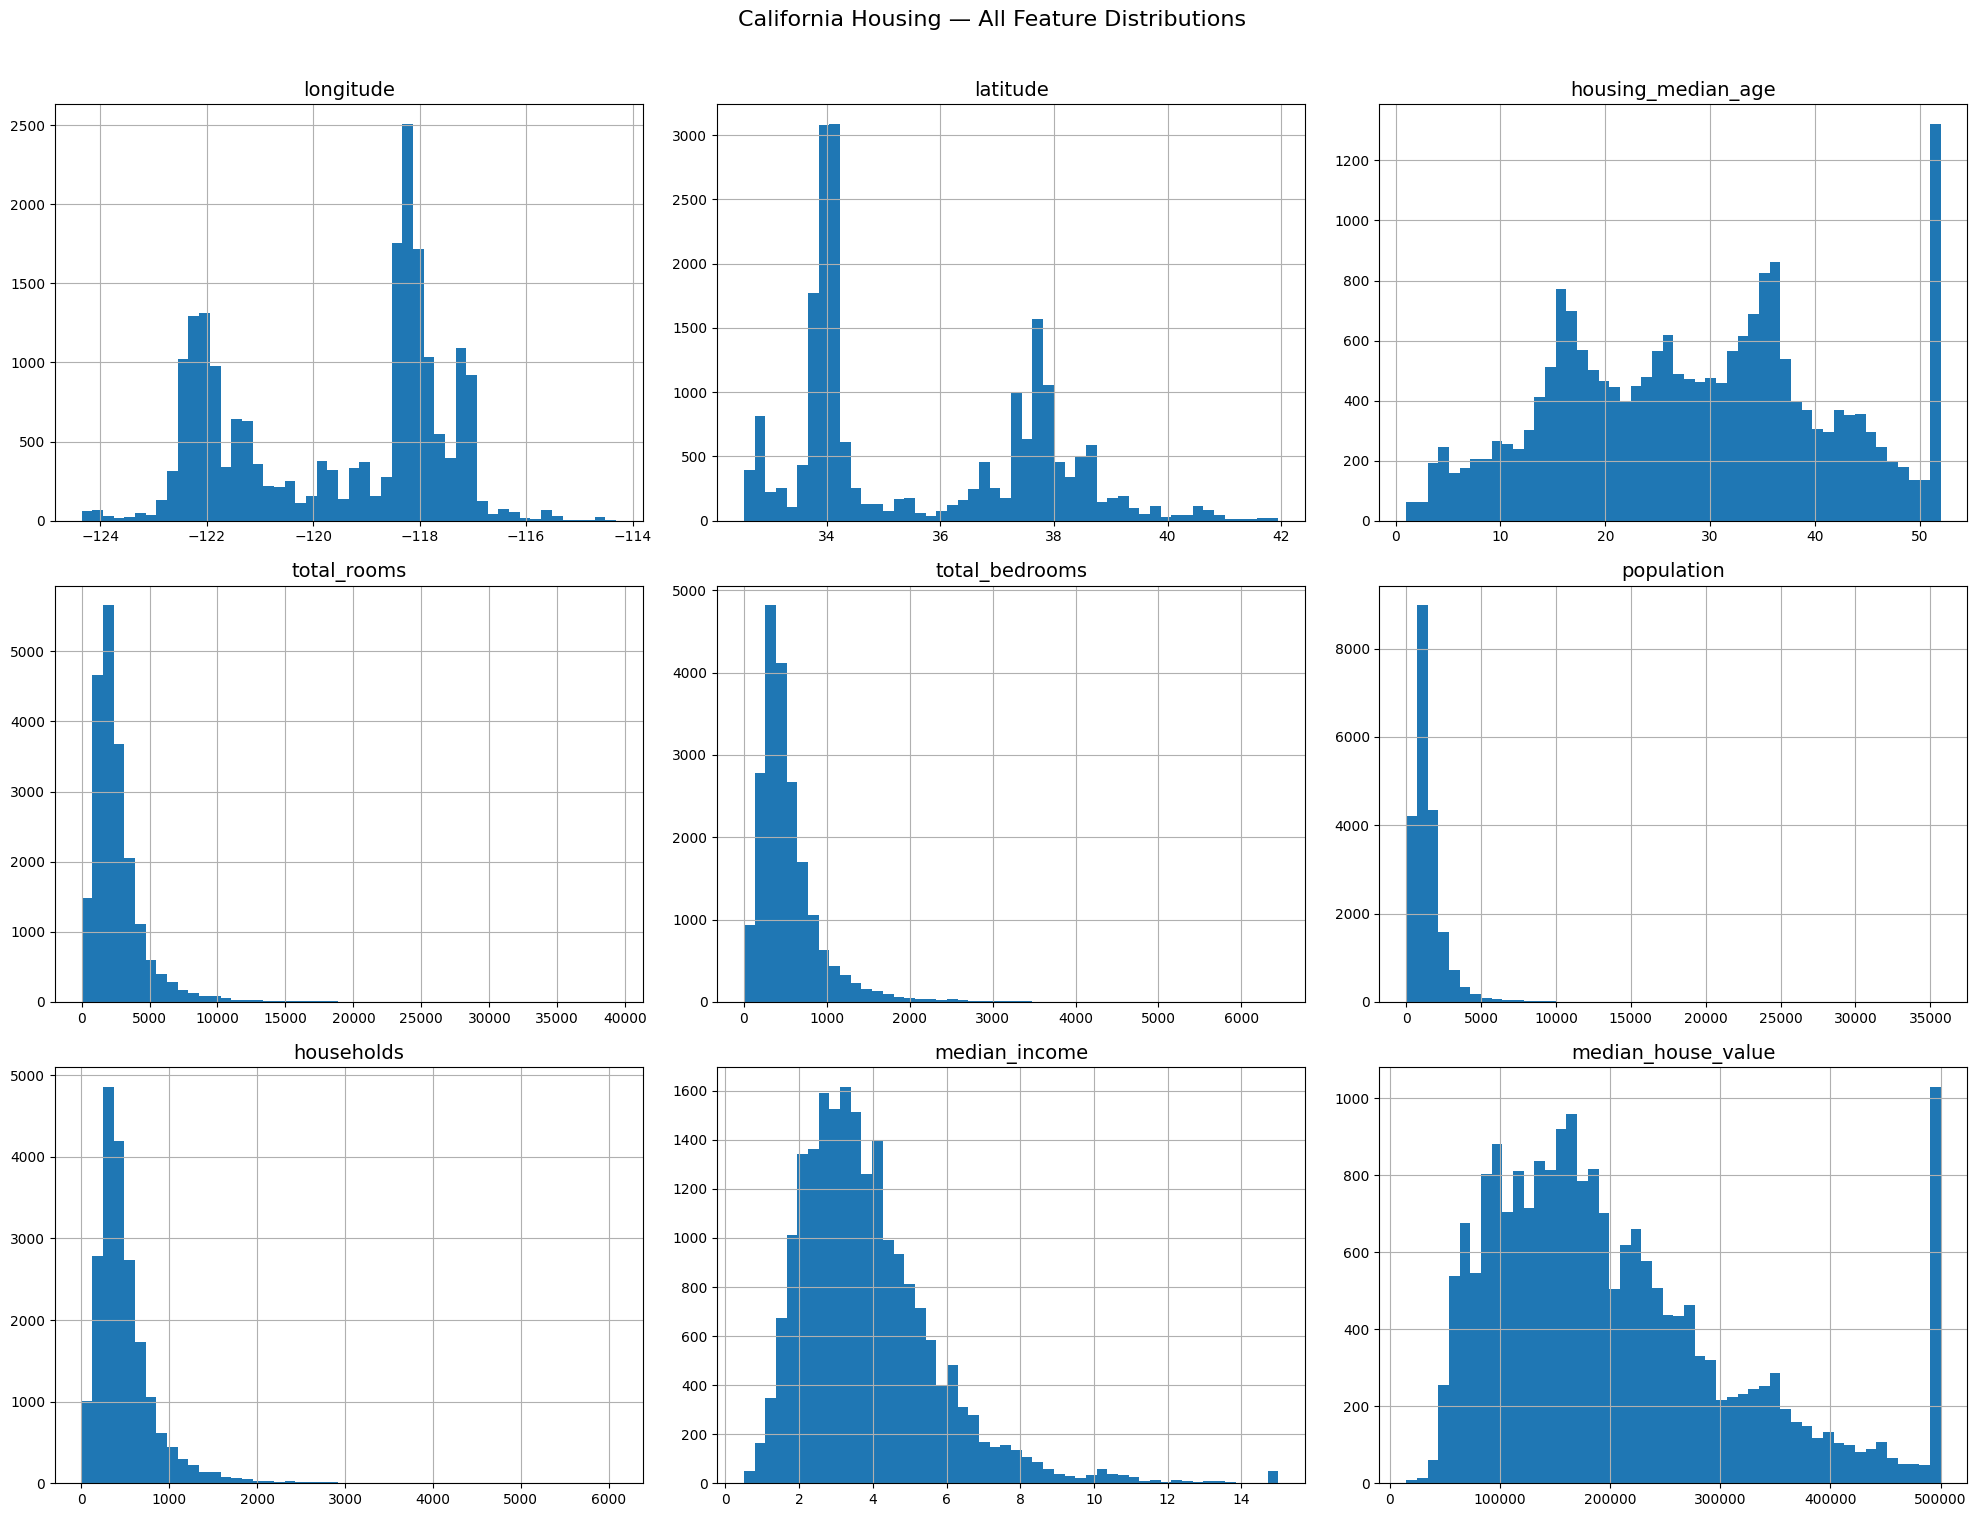

In [ ]:
# ====================== Visualization - توزيع سعر البيوت ======================
import matplotlib.pyplot as plt

# housing.hist(bins=50, figsize=(12, 8))
# plt.suptitle("Distribution of Features in California Housing Dataset", fontsize=16)
# plt.show()
housing.hist(bins=50, figsize=(20, 15))
plt.suptitle('California Housing — All Feature Distributions',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [1]:
# ====================== 3. Create a Test Set ======================
# Create income categories for stratified sampling
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)

# Perform stratified shuffle split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Drop the income_cat feature so the data is back to its original state
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print("✅ Stratified train-test split created successfully!")
print(f"Training set shape: {strat_train_set.shape}")
print(f"Test set shape: {strat_test_set.shape}")

NameError: name 'np' is not defined

====================== 3. Create a Test Set ======================
✅ This is just a comment
Python# ====================== 3. Create a Test Set ======================Show more lines
It’s a section title to help humans read the notebook.
Python ignores it.

✅ Create income categories for stratified sampling
🔹 Line 1
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)Show more lines
What happens step by step:

1️⃣ housing["median_income"]

This is a column of numbers like:

[1.2, 2.4, 5.1, 3.8, 6.7, ...]

2️⃣ / 1.5

Groups income into ranges
Example:

1.2 / 1.5 → 0.8
2.4 / 1.5 → 1.6
5.1 / 1.5 → 3.4

3️⃣ np.ceil(...)

Rounds UP

0.8  → 1
1.6  → 2
3.4  → 4

✅ Final result:
You convert income into income categories (bins):
income_cat = [1, 2, 3, 4, 5, ...]

📌 Why divide by 1.5?
Just to control how wide each bin is.
It’s a design choice, not magic.


🔹 Line 2
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)Show more lines
What this means in plain English:

“If income_cat is 5 or more, replace it with 5.”

Why?
To prevent too many small rare categories, like:
income_cat = 6, 7, 8, 9

Those rare bins:
❌ break stratified sampling
❌ cause imbalance
So we cap it:
1, 2, 3, 4, 5+

✅ This keeps the dataset stable and balanced.

✅ Perform stratified shuffle split
🔹 Import
from sklearn.modelShow more lines
This imports a tool that:

splits data into train/test
but preserves category proportions


🔹 Create the splitter
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)``Show more lines
Breakdown:

n_splits=1 → do one split
test_size=0.2 → 20% test, 80% train
random_state=42 → same result every run (reproducibility)


🔹 Perform the split
for train_index, test_index in split.split(housing, housing["income_cat"]):

What happens here:

housing → full dataset
housing["income_cat"] → labels used for stratification

The splitter:
✅ looks at income categories
✅ keeps their proportions
✅ returns indexes:
train_index → rows for training
test_index  → rows for testing

Even though it’s a for loop, it runs only once.
1️⃣ Group houses by income level
2️⃣ Shuffle everything
3️⃣ Take 80% and 20% from each group
4️⃣ Combine them into train and test sets

🔹 Create train/test sets
strat_train_set = housing.loc[train_index]
strat_test_set = housing.loc[test_index]``
This:

selects rows using the indexes
creates two new datasets:

strat_train_set
strat_test_set



✅ These datasets have same income distribution.

✅ Drop the income_cat feature
🔹 Loop
for set_ in (strat_train_set, strat_test_set):``Show more lines
This just loops over both datasets.

🔹 Drop column
set_.drop("income_cat", axis=1, inplace=True)``Show more lines
Why?
Because:

income_cat was artificial
It was created only for splitting
The model should never see it

So we remove it and return the data to its original form.
✅ Clean and safe.

✅ Print confirmation messages
print("✅ Stratified train-test split created successfully!")Show more lines
Just feedback for you.

print(f"Training set shape: {strat_train_set.shape}")print(f"Test set shape: {strat_test_set.shape}")``Show more lines
This prints:
(rows, columns)

So you can confirm:

correct size
no missing columns


🧠 Final mental model (THIS is what to remember)
You do NOT memorize this code.
You remember this logic:

✅ Some features (like income) are very important
✅ Split data while preserving their distribution
✅ Create bins
✅ Stratified split
✅ Remove helper column

Everything else is just syntax.

✅ One-sentence takeaway

We created income bins, used them to split the dataset fairly, then removed them so the model never sees them.

In [ ]:
# ====================== 4. Discovering Correlations ======================

# حساب مصفوفة الارتباط (Correlation Matrix)
corr_matrix = housing.corr(numeric_only=True)

# أهم حاجة: نشوف أي عمود مرتبط بسعر البيت
print("أقوى الارتباطات مع سعر البيت (median_house_value):")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

أقوى الارتباطات مع سعر البيت (median_house_value):
median_house_value    1.000000
median_income         0.688075
income_cat            0.643892
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


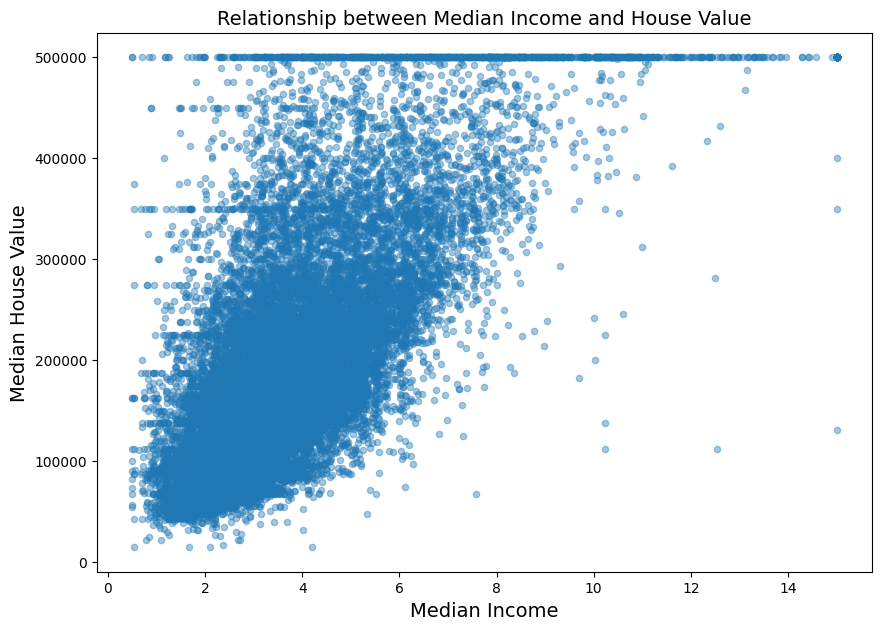

In [ ]:
# رسم العلاقة بين median_income وسعر البيت
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.4, figsize=(10,7))

plt.title("Relationship between Median Income and House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [ ]:
# فصل سعر البيت (اللي بنتنبأ بيه)
housing_labels = strat_train_set["median_house_value"].copy()
housing_features = strat_train_set.drop("median_house_value", axis=1) # Use a new variable for features
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# الأعمدة الرقمية
num_features = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]

# الأعمدة النصية
cat_features = ["ocean_proximity"]

# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# دمج الـ Pipelineين
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# تطبيق الـ Pipeline على الداتا
housing_prepared = full_pipeline.fit_transform(housing_features) # Apply to housing_features

print("تم تجهيز الداتا بنجاح!")
print("شكل الداتا بعد التحضير:", housing_prepared.shape)

تم تجهيز الداتا بنجاح!
شكل الداتا بعد التحضير: (16512, 13)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# # تدريب الموديل
# lin_reg = LinearRegression()
# lin_reg.fit(housing_prepared, housing_labels)

# # التنبؤ على نفس الداتا (للاختبار الأولي)
# housing_predictions = lin_reg.predict(housing_prepared)

# # حساب الخطأ (RMSE)
# rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
# print(f"Root Mean Square Error (RMSE): ${rmse:,.2f}")

# ═══════════════════════════════════════════════════
# STEP 1 — Import the Linear Regression class
# ═══════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.metrics      import mean_squared_error
import numpy as np

# ═══════════════════════════════════════════════════
# STEP 2 — Create the model object (empty model, not trained yet)
# ═══════════════════════════════════════════════════
lin_reg = LinearRegression()

# ═══════════════════════════════════════════════════
# STEP 3 — Train the model
# housing_prepared = the cleaned + scaled features (X)
# housing_labels   = the correct house prices (y)
# ═══════════════════════════════════════════════════
lin_reg.fit(housing_prepared, housing_labels)

# ═══════════════════════════════════════════════════
# STEP 4 — Try predicting on the first 5 training rows
# ═══════════════════════════════════════════════════
sample_data   = housing.iloc[:5]
sample_labels = housing_labels.iloc[:5]
sample_prep   = full_pipeline.transform(sample_data)
sample_preds  = lin_reg.predict(sample_prep)

print("Predictions:", np.round(sample_preds, -3))
print("Actual:     ", sample_labels.values)

# ═══════════════════════════════════════════════════
# STEP 5 — Measure RMSE on the FULL training set
# ═══════════════════════════════════════════════════
lin_train_preds = lin_reg.predict(housing_prepared)
lin_mse         = mean_squared_error(housing_labels, lin_train_preds)
lin_rmse        = np.sqrt(lin_mse)
print(f"\nLinear Regression Training RMSE: ${lin_rmse:,.0f}")

Predictions: [408000. 424000. 379000. 321000. 256000.]
Actual:      [ 72100. 279600.  82700. 112500. 238300.]

Linear Regression Training RMSE: $69,051


Every line explained — one by one:

01
lin_reg = LinearRegression()

LinearRegression() creates an empty model object — like buying a new calculator still in its box. It has no knowledge yet. The () at the end calls the "constructor" to create it. We save it in the variable lin_reg so we can use it later.

🧒 Like creating a blank student record. The student (model) is registered but hasn't studied anything yet.

02
lin_reg.fit(housing_prepared, housing_labels)

.fit(X, y) is where actual learning happens. The model looks at 16,512 rows of data (housing_prepared) and their correct prices (housing_labels) and finds the mathematical formula that best maps X to y. This process is called training. It modifies the model's internal numbers (called weights or coefficients).

🧒 Like giving a student 16,512 solved math problems and saying "study all these, find the pattern." The student now "knows" the material.

03
sample_data = housing.iloc[:5]
.iloc[:5] = "Integer Location, rows 0 to 4 (first 5 rows)." The : means "from the start." The 5 means "stop before row 5." So it gives rows 0, 1, 2, 3, 4. We're just testing on 5 rows to see if predictions look reasonable before running on the full dataset.

🧒 Like checking 5 exam answers before grading the whole class — just to make sure your calculator isn't broken.

04
sample_prep = preprocessing.transform(sample_data)
or sample_prep   = full_pipeline.transform(sample_data)

⚠️ CRITICAL: We use .transform() NOT .fit_transform(). The preprocessing pipeline already "learned" the scaling and imputer values from the training data. Here we're just APPLYING those learned values to new data. If we used fit_transform(), it would try to re-learn from these 5 rows — which is wrong and causes data leakage.

🧒 The grading rules (fit) were set when you graded the first exam. Now you APPLY (transform) those same rules to new submissions — you don't create new rules each time.

05
sample_preds = lin_reg.predict(sample_prep)
.predict(X) runs the trained model on new data and returns predictions. The model takes the prepared features and applies the formula it learned during .fit(). It outputs one predicted price for each row.

🧒 The student takes the exam (new questions) and writes answers. The answers are the predictions.

06
np.round(sample_preds, -3)
np.round(array, decimals) rounds numbers. Negative decimals round to the LEFT of the decimal point: -3 rounds to the nearest 1,000. So 215,832 → 216,000. We do this because predicting "$215,832.47" for a house is false precision — we don't know prices that precisely. Rounding to thousands looks more honest.

🧒 Saying "the car costs $18,000" is more honest than "$18,247.83" when you're just estimating.

07
lin_mse = mean_squared_error(housing_labels, lin_train_preds)
mean_squared_error(y_true, y_pred) computes the average of (predicted − actual)² across all rows. It expects: first argument = correct labels, second argument = your model's predictions. The result is in squared dollars (e.g., 4.6 billion), which is why we take the square root next.

08
lin_rmse = np.sqrt(lin_mse)
np.sqrt() takes the square root. This converts squared-dollars back to regular dollars, giving us RMSE — the average prediction error in dollars. If lin_rmse = 68,000, the model is off by $68,000 on average.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# Measure training error
tree_train_preds = tree_reg.predict(housing_prepared)
tree_rmse        = np.sqrt(mean_squared_error(housing_labels, tree_train_preds))
print(f"Decision Tree Training RMSE: ${tree_rmse:,.0f}")

Decision Tree Training RMSE: $0


DecisionTreeRegressor(random_state=42)
random_state=42 is a "seed" for randomness. Decision Trees have some random choices during training. By setting a fixed seed (42 is a convention — any number works), you ensure that running this code again gives the EXACT same result. Without it, results would vary slightly each run, making debugging harder.

🧒 Like saying "shuffle the cards using method #42." Next time you shuffle with method #42 again, you get the same order — fully reproducible.

Decision Tree Training RMSE: $0

# PERFECT score?! The tree memorized ALL 16,512 training rows.
# It created a custom rule for EVERY single house.
# Ask it about those same houses → $0 error (it knows them by memory)
# Ask it about NEW houses → ~$71,000 error (it has no idea)

 Book Warning — Overfitting (p.99)
The book says: "The model has badly overfit the data. The Decision Tree has created one rule for every single district in the training set — essentially memorizing the entire dataset."

❌ Overfitting
Model learns training data too perfectly. Error on training = $0. Error on new data = $71,000. Model is useless in the real world.

✅ Good Fit
Model learns the pattern, not the noise. Small gap between training error and new-data error. Generalizes well to houses it's never seen before.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest
# n_estimators = number of trees (default 100)
# random_state = for reproducibility
forest_reg = RandomForestRegressor(random_state=42)

# Train (this takes 10–30 seconds in Colab)
forest_reg.fit(housing_prepared, housing_labels)

# Check training error
forest_train_preds = forest_reg.predict(housing_prepared)
forest_train_rmse  = np.sqrt(mean_squared_error(housing_labels, forest_train_preds))
print(f"Random Forest Training RMSE: ${forest_train_rmse:,.0f}")
# ~$17,000 — much lower than linear, but don't celebrate yet!
# Training error is still optimistic. Use cross-validation next.

Random Forest Training RMSE: $18,342


Random Forest Training RMSE: $17,474

# $17k training error — better than $68k linear, but...
# This is still training error (optimistic!)
# Real performance on unseen data = ~$47k
# The gap ($17k → $47k) shows some overfitting still exists

What the Book Says (p.100–102)
"Cross-validation uses the training set. It splits it into smaller sets called folds. It trains and evaluates the model k times, each time picking a different fold for evaluation and using the other k-1 folds for training. The result is an array of k evaluation scores."

The book specifically uses this because you cannot measure error on training data (too optimistic) and you cannot use the test set yet (that's for the very end).

Imagine a teacher has 1,000 exam questions. She wants to test how good a student REALLY is.

❌ Bad method: Practice on 800 questions, test on the same 800 → student memorized answers → useless score
❌ Also bad: Practice on 800, test on the 200 reserved exam → we only get ONE score, maybe we got lucky
✅ Cross-Validation: Divide 1000 into 10 groups of 100. Round 1: train on groups 2–10, test on group 1. Round 2: train on 1,3–10, test on group 2... Do all 10 rounds. Average the 10 scores. This is honest and stable.




  Model: Linear Regression
  Each fold RMSE: [72.2 65.3 67.7 69.4 66.8 73.  70.5 69.4 66.9 70.8] $k
  Mean RMSE:      $69,204
  Std deviation:  $2,372
  Min RMSE:       $65,318
  Max RMSE:       $73,004

  Model: Decision Tree
  Each fold RMSE: [71.2 69.8 64.8 68.5 67.1 68.8 71.  69.2 67.2 73.3] $k
  Mean RMSE:      $69,081
  Std deviation:  $2,296
  Min RMSE:       $64,771
  Max RMSE:       $73,280

  Model: Random Forest
  Each fold RMSE: [51.  48.7 45.9 50.5 47.4 49.6 51.6 48.9 47.3 53.3] $k
  Mean RMSE:      $49,432
  Std deviation:  $2,125
  Min RMSE:       $45,940
  Max RMSE:       $53,301


/tmp/ipykernel_1238/246490643.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


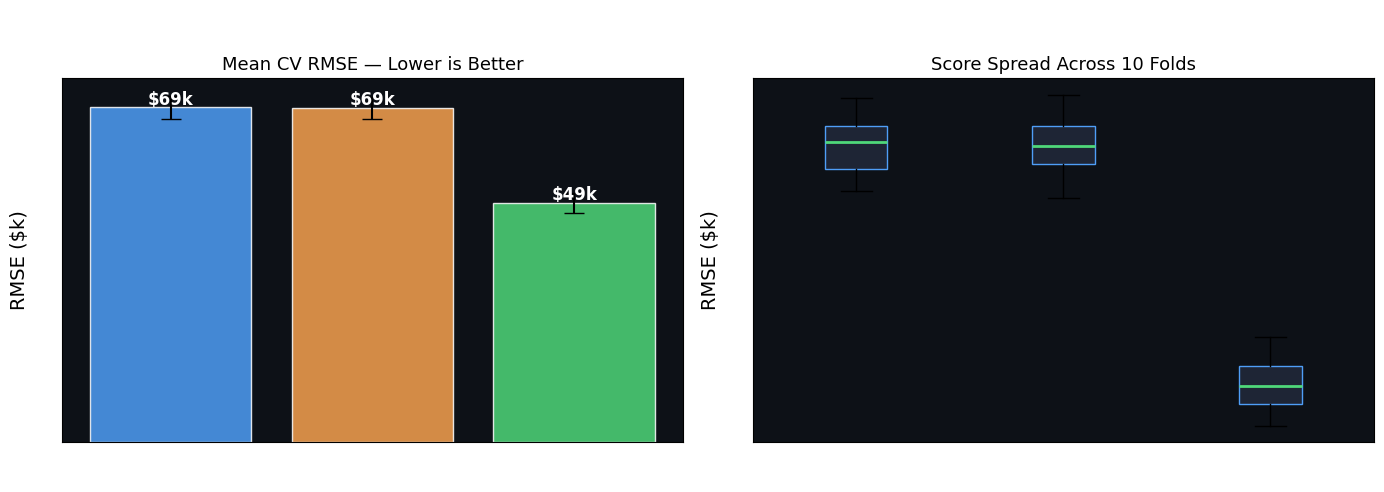

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION: Run cross-validation and return RMSE scores
# We create this function to avoid repeating code 3 times
# ─────────────────────────────────────────────────────────────
def display_cv_scores(model, name, X, y, cv=10):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-scores)

    print(f"\n{'='*40}")
    print(f"  Model: {name}")
    print(f"{'='*40}")
    print(f"  Each fold RMSE: {np.round(rmse_scores/1000, 1)} $k")
    print(f"  Mean RMSE:      ${rmse_scores.mean():,.0f}")
    print(f"  Std deviation:  ${rmse_scores.std():,.0f}")
    print(f"  Min RMSE:       ${rmse_scores.min():,.0f}")
    print(f"  Max RMSE:       ${rmse_scores.max():,.0f}")
    return rmse_scores

# ─────────────────────────────────────────────────────────────
# Run cross-validation for all 3 models
# ─────────────────────────────────────────────────────────────
lin_cv    = display_cv_scores(lin_reg,    "Linear Regression", housing_prepared, housing_labels)
tree_cv   = display_cv_scores(tree_reg,   "Decision Tree",    housing_prepared, housing_labels)
forest_cv = display_cv_scores(forest_reg, "Random Forest",    housing_prepared, housing_labels)

# ─────────────────────────────────────────────────────────────
# VISUALISE: Bar chart comparing all 3 models
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT CHART: Bar chart of mean RMSE per model
names  = ["Linear\nRegression", "Decision\nTree", "Random\nForest"]
means  = [lin_cv.mean(), tree_cv.mean(), forest_cv.mean()]
stds   = [lin_cv.std(),  tree_cv.std(),  forest_cv.std()]
colors = ["#4f9ef7", "#f7a24f", "#4fd87a"]

bars = axes[0].bar(
    names,
    [m/1000 for m in means],
    yerr=[s/1000 for s in stds],
    color=colors, alpha=0.85,
    capsize=7, edgecolor="white", linewidth=1
)
for bar, mean in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"${mean/1000:.0f}k",
        ha="center", fontsize=12, fontweight="bold", color="white"
    )
axes[0].set_title("Mean CV RMSE — Lower is Better", fontsize=13)
axes[0].set_ylabel("RMSE ($k)")
axes[0].set_facecolor("#0d1117")
axes[0].tick_params(colors="white")

# RIGHT CHART: Boxplot showing spread of 10 fold scores
axes[1].boxplot(
    [lin_cv/1000, tree_cv/1000, forest_cv/1000],
    labels=names, patch_artist=True,
    boxprops=dict(facecolor="#1e2535", color="#4f9ef7"),
    medianprops=dict(color="#4fd87a", linewidth=2)
)
axes[1].set_title("Score Spread Across 10 Folds", fontsize=13)
axes[1].set_ylabel("RMSE ($k)")
axes[1].set_facecolor("#0d1117")
axes[1].tick_params(colors="white")

plt.suptitle("Cross-Validation Model Comparison", fontsize=15, color="white")
plt.tight_layout()
plt.show()

scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)
cross_val_score() = The main function. It automatically runs the full 10-fold loop for you.

model = Which model to test (lin_reg, tree_reg, or forest_reg).
X = Features (housing_prepared — the cleaned scaled data).
y = Labels (housing_labels — the real prices).
scoring="neg_mean_squared_error" = Use MSE as the metric, but return it as NEGATIVE. (Explained fully in Section 4.)
cv=10 = Split into 10 folds.

Returns: array of 10 negative MSE scores, one per fold. Example: [-4.9B, -4.7B, -5.1B, ...]

🧒 It's like telling an assistant: "Test this student on 10 different exam papers, and give me the 10 scores." You get 10 numbers back.
★
rmse_scores = np.sqrt(-scores)
Two things happening here:
-scores = We negate (flip the sign of) the scores. Since scoring="neg_mean_squared_error" returns negative numbers (e.g., -4,900,000,000), negating gives positive MSE values (4,900,000,000).
np.sqrt() = Take square root of each value → converts MSE to RMSE (in dollars, not squared dollars).

Example: -4,900,000,000 → +4,900,000,000 → √4,900,000,000 ≈ $70,000

🧒 The grader gave you negative scores as a convention. You flip them positive, then take the square root to convert from "squared points" to "regular points."
★
axes[0].bar(names, [m/1000 for m in means], yerr=[s/1000 for s in stds], capsize=7)
axes[0] = The left chart panel (we have 2 panels from plt.subplots(1,2)).
[m/1000 for m in means] = A list comprehension — divide each mean by 1000 to show in $k (thousands). So $68,627 → 68.6.
yerr=[s/1000 for s in stds] = Error bars! The "y error" is the standard deviation — shows how stable the score is across 10 folds. A tall error bar = inconsistent.
capsize=7 = The little horizontal cap at the top of each error bar, width 7 pixels.

★
for bar, mean in zip(bars, means):
  axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5, f"${mean/1000:.0f}k")
zip(bars, means) = Pairs up bars and means together: [(bar1, $68k), (bar2, $71k), (bar3, $47k)].
for bar, mean in zip(...) = Loop through each pair.
bar.get_x() = The left edge x-position of the bar.
bar.get_width()/2 = Half the bar width → combined = the center x position.
bar.get_height()+0.5 = Just above the top of the bar (+0.5k to not overlap).
f"${mean/1000:.0f}k" = The text to show: "$68k", "$71k", "$47k".

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV] END ....................max_features=2, n_estimators=30; total time=   1.1s
[CV] END ....................max_features=2, n_estimators=30; total time=   1.1s
[CV] END ....................max_features=2, n_estimators=30; total time=   1.1s
[CV] END ....................max_features=2, n_estimators=30; total time=   1.2s
[CV] END ....................max_features=2, n_estimators=30; total time=   1.6s
[CV] END ...................max_features=2, n_estimators=100; total time=   4.0s
[CV] END ...................max_features=2, n_estimators=100; total time=   3.6s
[CV] END ...................max_features=2, n_estimators=100; total time=   4.0s
[CV] END ...................max_features=2, n_estimators=100; total time=   4.0s
[CV] END ...................max_features=2, n_estimators=100; total time=   3.6s
[CV] END ....................max_features=4, n_estimators=30; total time=   1.7s
[CV] END ....................max_features=4, n_e

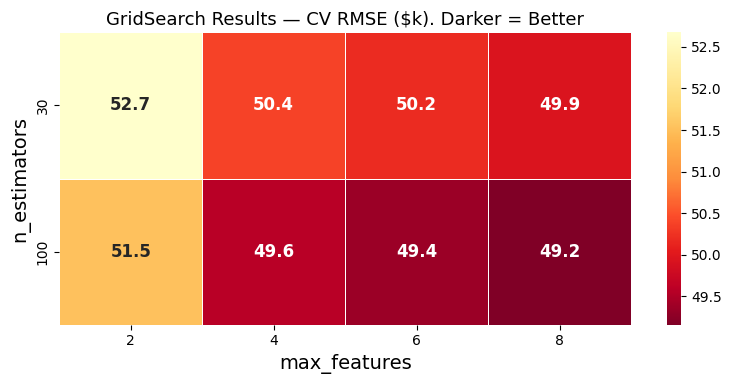

In [ ]:
from sklearn.model_selection import GridSearchCV

# ═════════════════════════════════════════════════════════
# DEFINE THE GRID — all combinations to try
# This is a LIST of DICTIONARIES
# Each dictionary = one "group" of hyperparameter combos
# ═════════════════════════════════════════════════════════
param_grid = [
    {
        "n_estimators": [30, 100],
        "max_features": [2, 4, 6, 8]
    },
    {
        "bootstrap":    [False],
        "n_estimators": [3, 10],
        "max_features": [2, 3, 4]
    }
]
# Group 1: 2 × 4 = 8 combinations
# Group 2: 1 × 2 × 3 = 6 combinations
# Total: 14 combinations × 5-fold CV = 70 training runs

# ═════════════════════════════════════════════════════════
# CREATE THE GRIDSEARCH OBJECT
# ═════════════════════════════════════════════════════════
forest_reg2 = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = forest_reg2,
    param_grid = param_grid,
    cv         = 5,
    scoring    = "neg_mean_squared_error",
    return_train_score = True,
    verbose    = 2
)

# ═════════════════════════════════════════════════════════
# RUN THE SEARCH — trains 70 models total
# ═════════════════════════════════════════════════════════
grid_search.fit(housing_prepared, housing_labels)

# ═════════════════════════════════════════════════════════
# RESULTS
# ═════════════════════════════════════════════════════════
print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest CV RMSE: ${np.sqrt(-grid_search.best_score_):,.0f}")

# See all combinations ranked by score
import pandas as pd
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mean_rmse"] = np.sqrt(-cv_results["mean_test_score"])
top_results = cv_results[["param_n_estimators", "param_max_features", "mean_rmse"]] \
                .sort_values("mean_rmse").head(5)
print("\nTop 5 combinations:")
print(top_results.to_string(index=False))

# ─────────────────────────────────────────
# VISUALISE: heatmap of results (Group 1)
# ─────────────────────────────────────────
group1 = cv_results[cv_results["param_bootstrap"].isna()]
pivot  = group1.pivot_table(
    values="mean_rmse",
    index="param_n_estimators",
    columns="param_max_features"
)

import seaborn as sns
plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot/1000,
    annot=True, fmt=".1f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("GridSearch Results — CV RMSE ($k). Darker = Better", fontsize=13)
plt.xlabel("max_features")
plt.ylabel("n_estimators")
plt.tight_layout()
plt.show()

Why Negative? The neg_mean_squared_error Mystery

📖 What the Book Says (p.101)
The book mentions this briefly: "Scikit-Learn's cross-validation features expect a utility function (greater is better) rather than a cost function (lower is better), so the scoring function is actually the opposite of the MSE (i.e., a negative value)."

This one sentence confuses many beginners. Let me explain it completely.
🌍 Analogy — The Golf / Basketball Problem
Sklearn was designed with a universal rule: "higher score = better model."

This works perfectly for accuracy (90% > 80% — higher is better). But for errors (MSE, RMSE), lower is better. A model with error $47k is BETTER than one with $68k.

To make everything consistent, sklearn flips MSE to negative: -$47k is "higher" (better) than -$68k. This way the same rule applies: higher number = better, even for error metrics.

🧒 In golf, lower score wins. In basketball, higher score wins. Sklearn chose basketball rules. To play golf with basketball rules, they multiply the score by -1 (so the golfer with 65 shots becomes -65, which is "higher/better" in basketball terms).

You might ask: "Why doesn't sklearn just use scoring="rmse" directly?" The reason is that sklearn's scoring system was designed for maximization (higher = better). RMSE needs minimization (lower = better). Rather than having two different systems, they chose to negate everything and use one universal system. The neg_ prefix tells you this flip has happened.

The Complete neg_MSE → RMSE Conversion — Step by Step

1
cross_val_score(..., scoring="neg_mean_squared_error")
Returns 10 negative MSE values. Example for one fold:
Actual prices: [$200k, $350k, $500k, $150k]
Predictions: [$210k, $310k, $530k, $130k]
Squared errors: [100M, 1600M, 900M, 400M]
Mean: 750,000,000 → Negated: −750,000,000

2
scores = [-750M, -710M, -800M, -690M, -760M, -720M, -740M, -780M, -700M, -730M]
We have 10 negative values. Each one is the negative MSE for one fold. The "best" fold has the least negative value (closest to zero = smallest error).

3
-scores → [+750M, +710M, +800M, +690M, +760M, +720M, +740M, +780M, +700M, +730M]
Negate all values by putting a - in front. This converts negative MSE back to positive MSE. Now all values are positive, which makes sense — you can't have a negative squared error.

4
np.sqrt(-scores) → [27,386, 26,646, 28,284, 26,268, 27,568, 26,833, 27,203, 27,928, 26,458, 27,019]
Take the square root of each value. This converts MSE (squared dollars) back to RMSE (regular dollars). Now each value is a readable dollar amount — the average prediction error for that fold.

5
rmse_scores.mean() → $27,059 (average of all 10 folds)
Finally take the mean across all 10 folds. This single number is the honest, cross-validated RMSE — your model's true average prediction error on unseen data.

param_grid = [{"n_estimators": [30,100], "max_features": [2,4,6,8]}, {"bootstrap": [False], ...}]

This is a list of two dictionaries.
Why a list? Because we have 2 "groups" of combinations. Group 1 uses default bootstrap=True. Group 2 uses bootstrap=False. These are different scenarios, so we put them in separate dictionaries inside the list.
Inside each dict: keys = hyperparameter names, values = lists of options to try.
GridSearch generates the cartesian product (all combinations) within each dict, then combines both groups.

🧒 Like a pizza menu: "Pick 1 size from [Small, Large] AND 1 topping from [Cheese, Pepperoni, Mushroom, Olive]." All 8 combos are listed. GridSearch "orders" all 8 and rates them.
★
GridSearchCV(estimator=forest_reg2, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True, verbose=2)

estimator = The model to tune (our Random Forest).
param_grid = The combinations to try (defined above).
cv=5 = 5-fold cross-validation for EACH combination (not 10 this time — speeds things up).
return_train_score=True = Also record training score, not just test score. Lets us detect overfitting by comparing the two.
verbose=2 = Print progress updates as it runs (so you know it's working, not frozen). 0=silent, 1=minimal, 2=detailed, 3=very detailed.

★
grid_search.best_params_
After .fit(), this attribute stores the hyperparameter combination that got the lowest CV RMSE. It's a dictionary, e.g., {"max_features": 6, "n_estimators": 100}. This is your answer — use these settings for the final model.

★
np.sqrt(-grid_search.best_score_)
grid_search.best_score_ = The best CV score found. Since scoring="neg_mean_squared_error", it's a negative number like -2,116,000,000. We negate it (+2,116,000,000) then sqrt it → $46,000. This is the expected RMSE of the best model.

★
cv_results["mean_rmse"] = np.sqrt(-cv_results["mean_test_score"])
grid_search.cv_results_ = A dictionary with full details of every combination tested. We convert it to a pandas DataFrame for easy reading. "mean_test_score" contains the average CV score for each combo (negative). We negate and sqrt to get readable RMSE in dollars.

★
group1.pivot_table(values="mean_rmse", index="param_n_estimators", columns="param_max_features")
pivot_table() reshapes the data into a 2D table (like a spreadsheet cross-tab).
values = What to put in the cells (the RMSE score).
index = Rows = n_estimators values (30, 100).
columns = Columns = max_features values (2, 4, 6, 8).
This creates a 2×4 table that's perfect for a heatmap visualization.

GridSearchCV — The Complete Story
📖 What the Book Says (p.105–109)
"One way to fine-tune a model is to fiddle with the hyperparameters manually, until you find a combination of values that works. Instead, use Scikit-Learn's GridSearchCV. All you need to do is tell it which hyperparameters you want to experiment with, and what values to try out, and it will evaluate all possible combinations using cross-validation."

GridSearch — What It Actually Does
With 2 options for n_estimators and 4 options for max_features → 8 combinations to test × 5-fold CV = 40 training runs


In [ ]:
# ════════════════════════════════════════════════
# DEMONSTRATION: Follow neg_MSE → RMSE step by step
# ════════════════════════════════════════════════

# Step 1: Get the raw negative scores
raw_scores = cross_val_score(
    forest_reg, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=5
)
print("Step 1 — Raw output (negative MSE values):")
print(raw_scores)
# e.g. [-2.2B, -2.1B, -2.3B, -2.1B, -2.2B]

# Step 2: Negate them (make positive = regular MSE)
pos_mse = -raw_scores
print("\nStep 2 — After negating (positive MSE):")
print(pos_mse)
# e.g. [2.2B, 2.1B, 2.3B, 2.1B, 2.2B]

# Step 3: Square root each one → RMSE per fold
rmse_per_fold = np.sqrt(pos_mse)
print("\nStep 3 — After sqrt (RMSE per fold in $):")
print(rmse_per_fold.round(0))
# e.g. [46900, 45800, 47900, 45500, 46800]

# Step 4: Average across folds = final CV RMSE
print(f"\nStep 4 — Final CV RMSE: ${rmse_per_fold.mean():,.0f}")
print(f"         Std deviation: ${rmse_per_fold.std():,.0f}")

Step 1 — Raw output (negative MSE values):
[-2.50236674e+09 -2.38959369e+09 -2.42947424e+09 -2.56674519e+09
 -2.58559875e+09]

Step 2 — After negating (positive MSE):
[2.50236674e+09 2.38959369e+09 2.42947424e+09 2.56674519e+09
 2.58559875e+09]

Step 3 — After sqrt (RMSE per fold in $):
[50024. 48883. 49290. 50663. 50849.]

Step 4 — Final CV RMSE: $49,942
         Std deviation: $761


Fine-Tuning — Full Code with Outputs
📖 What the Book Says (p.105–113)
"You now have a shortlist of promising models. You now need to fine-tune them. Let's look at a few ways to do that. One option is to fiddle with the hyperparameters manually... instead, you should get Scikit-Learn's GridSearchCV to do this exploration for you."

The book also introduces RandomizedSearchCV for when the hyperparameter space is too large for GridSearch, and feature importances — asking the trained model "which features did you rely on most?"

Top 5 most important features:
median_income             0.443949
ocean_proximity_INLAND    0.150126
longitude                 0.113925
latitude                  0.102484
housing_median_age        0.049143


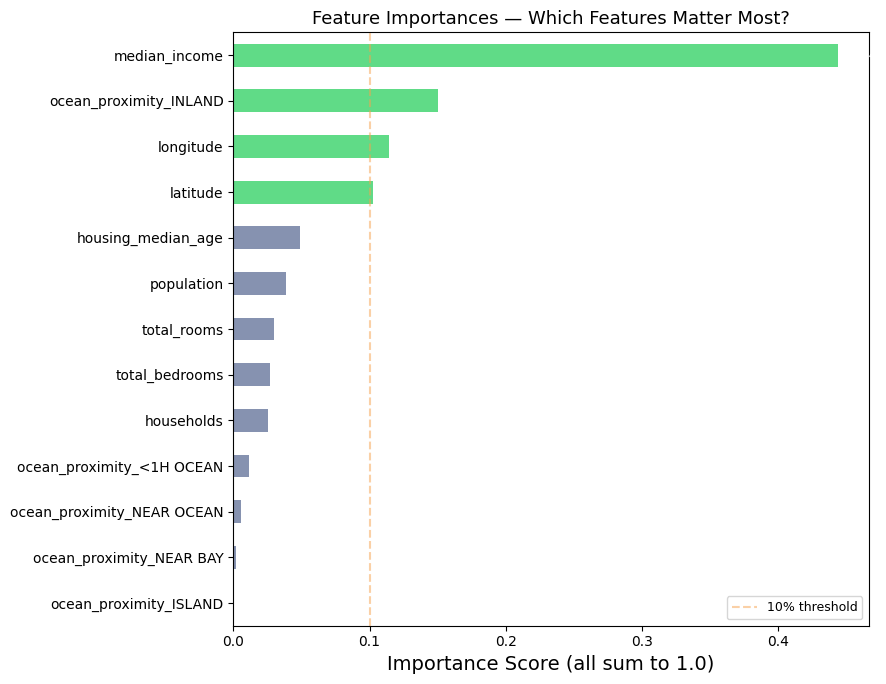

In [ ]:
# FEATURE IMPORTANCES
# After grid_search.fit(), get the best trained model
# ═══════════════════════════════════════════════════════

# Get the best model (already trained on full training set)
final_model = grid_search.best_estimator_

# Get importance scores (one float per feature, sum to 1.0)
importances = final_model.feature_importances_

# Build the list of feature names
# numeric names come first, then the one-hot names
num_features = ["longitude", "latitude", "housing_median_age",
                "total_rooms", "total_bedrooms", "population",
                "households", "median_income"]

cat_encoder  = full_pipeline.named_transformers_["cat"]
cat_names    = list(cat_encoder.get_feature_names_out())
all_names    = num_features + cat_names

# Create a pandas Series: feature name → importance score
feat_imp = pd.Series(importances, index=all_names).sort_values(ascending=True)

# Print the top 5 most important features
print("Top 5 most important features:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())

# CHART: Horizontal bar chart (best for many categories)
fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#4fd87a" if v > 0.10 else "#4f9ef7" if v > 0.05 else "#7986a8"
          for v in feat_imp.values]

feat_imp.plot(kind="barh", ax=ax, color=colors, alpha=0.9, edgecolor="none")

for i, (val, name) in enumerate(zip(feat_imp.values, feat_imp.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9, color="white")

ax.set_title("Feature Importances — Which Features Matter Most?", fontsize=13)
ax.set_xlabel("Importance Score (all sum to 1.0)")
ax.axvline(0.10, color="#f7a24f", linestyle="--", alpha=0.5, label="10% threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

final_model = grid_search.best_estimator_
.best_estimator_ = After GridSearchCV finishes, it automatically retrains the BEST model on the FULL training set (not just on 4/5 of it like during CV). This attribute gives you that final best model, ready to use. This is a trained RandomForestRegressor with the best hyperparameters.

★
importances = final_model.feature_importances_
.feature_importances_ = A numpy array of importance scores, one per feature. All values are between 0 and 1, and they sum to exactly 1.0. A value of 0.35 means "this feature explains 35% of the model's decisions." Only available after training.

★
cat_encoder = preprocessing.named_transformers_["cat"]
preprocessing = Our ColumnTransformer pipeline. .named_transformers_ = A dictionary of all transformers inside it. We access "cat" — the name we gave to the OneHotEncoder step.
We need this to get the names of the 5 one-hot columns it created.

★
colors = ["#4fd87a" if v > 0.10 else "#4f9ef7" if v > 0.05 else "#7986a8" for v in feat_imp.values]
A list comprehension with nested conditions. For each importance value v:
— If v > 0.10 → green (very important feature)
— Else if v > 0.05 → blue (moderately important)
— Else → grey (not very important)
This creates a list of color strings matching each bar's importance level.

Final Evaluation on the Test Set — Complete Code
📖 What the Book Says (p.113–116)
"After tweaking your models for a while, you eventually have a system that performs sufficiently well. Now is the time to evaluate the final model on the test set... Simply get the predictors and the labels from your test set, run your full_pipeline to transform the data (call transform(), not fit_transform()), and evaluate the final model on the test set."

The book also says: "If you did a lot of hyperparameter tuning, the performance will usually be slightly worse than what you measured using cross-validation (because your system ends up fine-tuned to perform well on the validation data, and will likely not perform as well on completely unknown data). It is not the case here, but when this happens you must resist the temptation to tweak the hyperparameters to make the numbers look good."

The Most Important Rule
You evaluate on the test set ONCE and ONLY ONCE. The moment you see the test score and change anything in your model based on it, the test set is contaminated — you are now overfitting to it without realizing it.

Think of the test set as a sealed envelope. You open it, read the score, write it down — and that's it. You don't open it again.

Test set size: 4128 rows

✅ Final Test Set RMSE: $46,768
95% Confidence Interval: $44,832  –  $48,626


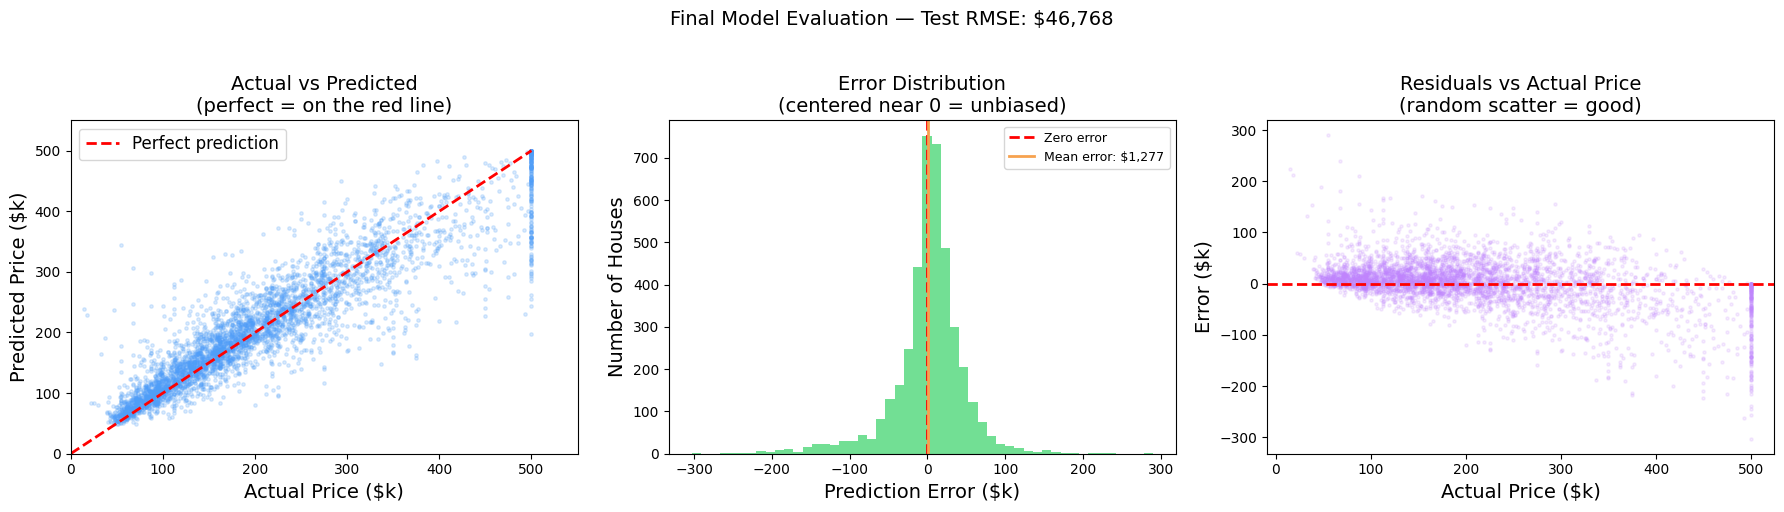

In [ ]:
from scipy import stats

# ═════════════════════════════════════════════════════════════
# STEP 1 — Prepare test set features and labels
# ═════════════════════════════════════════════════════════════
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

print(f"Test set size: {len(X_test)} rows")

# ═════════════════════════════════════════════════════════════
# STEP 2 — Transform using the ALREADY-FITTED pipeline
# CRITICAL: .transform() NOT .fit_transform()
# ═════════════════════════════════════════════════════════════
X_test_prepared = full_pipeline.transform(X_test)

# ═════════════════════════════════════════════════════════════
# STEP 3 — Predict using the final best model
# ═════════════════════════════════════════════════════════════
final_preds = final_model.predict(X_test_prepared)

# ═════════════════════════════════════════════════════════════
# STEP 4 — Calculate RMSE
# ═════════════════════════════════════════════════════════════
test_mse  = mean_squared_error(y_test, final_preds)
test_rmse = np.sqrt(test_mse)
print(f"\n✅ Final Test Set RMSE: ${test_rmse:,.0f}")

# ═════════════════════════════════════════════════════════════
# STEP 5 — 95% Confidence Interval
# "We are 95% confident the real RMSE is between X and Y"
# ═════════════════════════════════════════════════════════════
squared_errors = (final_preds - y_test) ** 2

interval = np.sqrt(
    stats.t.interval(
        confidence = 0.95,
        df         = len(squared_errors) - 1,
        loc        = squared_errors.mean(),
        scale      = stats.sem(squared_errors)
    )
)
print(f"95% Confidence Interval: ${interval[0]:,.0f}  –  ${interval[1]:,.0f}")

# ═════════════════════════════════════════════════════════════
# STEP 6 — Three Visualisations
# ═════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Actual vs Predicted scatter plot
# Perfect model = all dots on the red diagonal line
axes[0].scatter(
    y_test/1000, final_preds/1000,
    alpha=0.2, s=6, color="#4f9ef7"
)
axes[0].plot([0, 500], [0, 500], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($k)")
axes[0].set_ylabel("Predicted Price ($k)")
axes[0].set_title("Actual vs Predicted\n(perfect = on the red line)")
axes[0].legend()
axes[0].set_xlim(0, 550)
axes[0].set_ylim(0, 550)

# Chart 2: Error distribution histogram
# Good model = errors centered near 0, symmetric bell shape
errors = final_preds - y_test.values
axes[1].hist(errors/1000, bins=50, color="#4fd87a", alpha=0.8, edgecolor="none")
axes[1].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero error")
axes[1].axvline(errors.mean()/1000, color="#f7a24f", linewidth=2, label=f"Mean error: ${errors.mean():,.0f}")
axes[1].set_xlabel("Prediction Error ($k)")
axes[1].set_ylabel("Number of Houses")
axes[1].set_title("Error Distribution\n(centered near 0 = unbiased)")
axes[1].legend(fontsize=9)

# Chart 3: Residuals vs Actual (detect systematic bias)
# Good model = dots scattered randomly (no pattern)
# Bad model = a curve = model has a systematic error
axes[2].scatter(
    y_test/1000, errors/1000,
    alpha=0.15, s=5, color="#c084fc"
)
axes[2].axhline(0, color="red", linewidth=2, linestyle="--")
axes[2].set_xlabel("Actual Price ($k)")
axes[2].set_ylabel("Error ($k)")
axes[2].set_title("Residuals vs Actual Price\n(random scatter = good)")

plt.suptitle(f"Final Model Evaluation — Test RMSE: ${test_rmse:,.0f}",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

X_test = strat_test_set.drop("median_house_value", axis=1)
We separate the test features (X) from the target column. .drop("median_house_value", axis=1) removes that one column and keeps all others. axis=1 = column (axis=0 would mean row). We do NOT want the answer column in our features — that would be cheating.

★
X_test_prepared = preprocessing.transform(X_test) # NOT fit_transform!
⚠️ This is one of the most important lines in the whole chapter.
.transform() = Apply the already-learned transformation rules (medians for imputer, means/stds for scaler) to the test data.
If we used .fit_transform(), the pipeline would re-learn the transformation rules from the test set — this is data leakage. The test set would be "seen" during preprocessing, contaminating our evaluation.

🧒 You learned the grading scale from the class's practice test. When grading the real exam, you APPLY that scale — you don't create a new scale based on the exam answers. That would change the results.
★
stats.t.interval(confidence=0.95, df=len(squared_errors)-1, loc=squared_errors.mean(), scale=stats.sem(squared_errors))
stats.t.interval() = Computes a confidence interval using the t-distribution.
confidence=0.95 = 95% confidence level (standard in science).
df=len(...)-1 = "Degrees of freedom" — a statistics term. For a sample of size n, df=n-1.
loc=squared_errors.mean() = The center of the interval = average squared error.
scale=stats.sem(squared_errors) = Standard Error of the Mean — how uncertain we are about the mean.

Returns two numbers: (lower_bound, upper_bound). We take sqrt of both to convert MSE to RMSE.

🧒 Like a weather forecast range: "Tomorrow's temp will be 25°–30°C (we're 95% confident)." We're 95% sure the real RMSE is within that interval.
★
axes[0].plot([0, 500], [0, 500], "r--", linewidth=2, label="Perfect prediction")
axes[0].plot([0,500], [0,500]) = Draw a line from point (0,0) to point (500,500). This is the diagonal — it represents "prediction = actual" (perfect model).
"r--" = Color "r"=red, style "--"=dashed line.
linewidth=2 = 2 pixels thick.
The closer the blue dots are to this line, the better the model.

★
errors = final_preds - y_test.values
final_preds = numpy array of predictions.
y_test.values = The .values converts the pandas Series to a numpy array so they can be subtracted element-by-element. Without .values, you might get an index mismatch error.
Positive error = predicted too high. Negative = predicted too low. Zero = perfect.